# Reverse Image Search featuring Impressionist Paintings

# 印象派绘画的反向图像搜索

使用向量数据库，可以轻松在本地搭建自己的反向图像搜索系统。我们采用 Milvus Lite 和 PyTorch，结合 Kaggle 上的 Impressionist-Classifier 数据集，构建了一个本地的反向图像搜索模型。

首先，我们导入必要的库：

In [1]:
import os

CUSTOM_CACHE = r'F:\Teewon\Milvue\models'

os.environ['HF_HOME'] = CUSTOM_CACHE
os.environ['HF_HUB_CACHE'] = os.path.join(CUSTOM_CACHE, 'hub')
os.environ['TRANSFORMERS_CACHE'] = os.path.join(CUSTOM_CACHE, 'transformers')

os.environ['TORCH_HOME'] = CUSTOM_CACHE


In [2]:
#! pip install pymilvus==2.2.5 torch gdown torchvision tqdm milvus

接下来，我们使用 gdown 从公开托管的 Google Drive 下载数据集，并用 zip 文件解压图像。

In [3]:
# import gdown
# import zipfile
#
# url='https://drive.google.com/uc?id=1OYDHLEy992qu5C4C8HV5uDIkOWRTAR1_'
# output='./paintings.zip'
# gdown.download(url, output)
#
# with zipfile.ZipFile(output, 'r') as zip_ref:
#     zip_ref.extractall('./paintings')

下载完所有图片后，我们需要设置一些参数，以便后续与我们的向量数据库进行操作。

In [4]:
# Collection Setup params
COLLECTION_NAME='image_search'
DIMENSION=2048 # Embedding vector size in this example

# Inference Arguments 用于查询
BATCH_SIZE = 128
TOP_K = 3


Let's start our local Vector Database instance with Milvus Lite

In [5]:
from pymilvus import MilvusClient, DataType

mc=MilvusClient('../milvus_demo.db')

print(f"Type of server: {mc.get_server_version()}")

Type of server: milvus_lite-3.1.1


服务器启动后，我们就可以开始工作了。首先，我们需要定义向量数据库的模式并创建一个集合。集合中的每个条目包含三个字段：首先是用于常规查询的ID，其次是本地存储图像的文件路径，最后是用于相似度搜索的嵌入向量。

In [6]:
# Check that the collection does not yet exist
has=mc.has_collection(COLLECTION_NAME)
if has:
    mc.drop_collection(COLLECTION_NAME)
    print(f"Successfully dropped collection: {COLLECTION_NAME}")

# Milvus 3.0
schema=mc.create_schema(enable_dynamic_field=False)
schema.add_field(field_name='id',datatype=DataType.INT64,is_primary=True,auto_id=True)
schema.add_field(field_name='filepath',datatype=DataType.VARCHAR,max_length=200)
schema.add_field(field_name='image_embedding',datatype=DataType.FLOAT_VECTOR,dim=DIMENSION)

# mc.create_collection(
#     collection_name=COLLECTION_NAME,
#     schema=schema,
# )

Successfully dropped collection: image_search


{'auto_id': True, 'description': '', 'fields': [{'name': 'id', 'description': '', 'type': <DataType.INT64: 5>, 'is_primary': True, 'auto_id': True}, {'name': 'filepath', 'description': '', 'type': <DataType.VARCHAR: 21>, 'params': {'max_length': 200}}, {'name': 'image_embedding', 'description': '', 'type': <DataType.FLOAT_VECTOR: 101>, 'params': {'dim': 2048}}], 'enable_dynamic_field': False, 'enable_namespace': False}

一旦我们连接到向量数据库并创建了数据集，就可以建立索引以便进行搜索。在此示例中，我们使用基于L2范数的IVF平铺索引，并设置128个聚类单元（`nlist`）。

点击此处了解有关向量索引的更多信息。

In [7]:
index_params={
    "field_name": "image_embedding",
    "index_type":"IVF_FLAT",
    "metric_type":"L2",
    "params":{"nlist": 128}
}

mc.create_collection(
    COLLECTION_NAME,
    consistency_level="Eventually",
    params=index_params,
    schema=schema,
)

现在我们来获取嵌入向量。我们使用 PyTorch 中的 ResNet50 模型来生成嵌入向量。通常情况下，ResNet50 模型的最后一个层会输出数据集的分类结果。但在我们的场景中，我们需要的是嵌入向量而不是分类结果，因此需要移除最后一层。

In [8]:
import glob
paths=glob.glob('data/paintings/paintings/**/*.jpg', recursive=True)
print(len(paths))

4978


In [9]:
import torch
import torchvision.models as models

torch.backends.cudnn.deterministic=True
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"DEVICE: {DEVICE}")

# Load the embedding model with the last layer removed
    # the last layer is the classification layer, the embeddings are the layer right before
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model = torch.nn.Sequential(*(list(model.children())[:-1]))
model.eval()

DEVICE: cuda


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, ker

此时，我们已经有一个本地的 Milvus 实例在运行，包含了本示例项目的数据，以及我们需要用来生成嵌入向量的模型。下一步是将数据上传到向量数据库中，并进行索引处理。首先，我们需要对数据进行预处理，使其与 ResNet50 模型训练所用的数据格式一致（页面底部可见）。然后，我们将数据分批处理并“上传”至我们的向量数据库。

这一步的第二阶段需要一些时间运行（在 16GB 内存的 M1 Mac 上大约需要 12 分钟），目前我们已将近 5000 张图像通过 ResNet50 进行了处理，现在正是吃点零食或喝点东西的好时机 :)

In [10]:
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

preprocess=transforms.Compose([
    transforms.Resize(256), # 将图片的最短边缩放至 256 像素（保持宽高比）
    transforms.CenterCrop(224), # 从图片正中心裁剪出 224×224 像素的正方形区域
    transforms.ToTensor(), # 将 PIL 图像（像素值 0~255）转换为 PyTorch 张量，并归一化像素值到 [0.0, 1.0]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
])

In [16]:
def embed(data,model):
    with torch.no_grad():
        outputs=model(torch.stack(data[0]))
        outputs = outputs.view(outputs.size(0), -1)
        vectors=outputs.tolist()
    return vectors

In [17]:
data_batch=[[],[]]

for path in tqdm(paths):
    im=Image.open(path).convert('RGB')
    data_batch[0].append(preprocess(im))
    data_batch[1].append(path)
    if len(data_batch[0]) % BATCH_SIZE == 0:
        # 1. 提取特征
        vectors=embed(data_batch,model)

        # 2. 构造插入数据：字典列表
        insert_data=[
            {"filepath":path,"image_embedding":vec}for path,vec in zip(data_batch[1],vectors)]

        # 3. 批量插入 Milvus
        res=mc.insert(
            collection_name=COLLECTION_NAME,
            data=insert_data,
            progress_bar=True,)
        # print(f"Inserted {res['insert_count']} entities")

        # 4. 清空批次，准备下一批
        data_batch=[[],[]]

if len(data_batch[0]):
    vectors=embed(data_batch,model)
    insert_data = [
        {"filepath": path, "image_embedding": vec}
        for path, vec in zip(data_batch[1], vectors)
    ]
    mc.insert(collection_name=COLLECTION_NAME, data=insert_data,    progress_bar=True)

  3%|▎         | 134/4978 [00:08<20:45,  3.89it/s]

Inserted 128 entities


  5%|▌         | 265/4978 [00:17<17:22,  4.52it/s]

Inserted 128 entities


  8%|▊         | 387/4978 [00:26<24:39,  3.10it/s]

...

 95%|█████████▌| 4748/4978 [04:58<00:35,  6.49it/s]

Inserted 128 entities


 98%|█████████▊| 4863/4978 [04:59<00:01, 78.02it/s]

Inserted 128 entities


100%|██████████| 4978/4978 [05:07<00:00, 16.17it/s]


在我们的向量数据库中填充完毕后，即可进行反向图像搜索。本节的第二部分展示了如何选择一张或多张图像进行反向图像搜索。在此示例中，我们有两个搜索模式：第一个（已注释）展示了如何搜索提供的测试画作；第二个则展示了如何对训练集中指定的一幅画进行反向图像搜索。大多数情况下，在进行任何类型的验证时使用训练数据都是不推荐的做法，但这个具体案例证实了：当对存在于向量数据库中的图像执行反向图像搜索时，我们能够返回相同的图像。

In [26]:
import time
from matplotlib import pyplot as plt

# modify `search_paths` to modify which images you reverse search

# the below example shows how to search for the most similar results to two images in the test set
search_paths = glob.glob('data/paintings/test_paintings/**/*.jpg', recursive=True)
print(len(search_paths))
# the below example shows how to search for a specific image in the training set
# we expect to get the same image back as the "most similar" image
search_path=glob.glob('data/paintings/paintings/training/training/Degas/213255.jpg', recursive=True)
print(len(search_path))

2
1


In [ ]:
def embed_query(data,model):
    with torch.no_grad():
        ret=model(torch.stack(data))
        return ret.view(ret.size(0), -1).tolist()
SEARCH_PARAMS=dict({
    "metric_type":"L2",
    "params":{"nprobe":10}
})

In [27]:
data_batch=[[],[]]

for path in search_paths:
    im=Image.open(path).convert('RGB')
    data_batch[0].append(preprocess(im))
    data_batch[1].append(path)

embeds_query=embed_query(data_batch[0],model)
start=time.time()
res=mc.search(
    collection_name=COLLECTION_NAME,
    data=embeds_query,
    search_params=SEARCH_PARAMS,
    limit=TOP_K,
    output_fields=["filepath"]
)
end_time=time.time()

print(f"Search completed in {end_time - start:.3f} seconds.")

Search completed in 3.963 seconds.


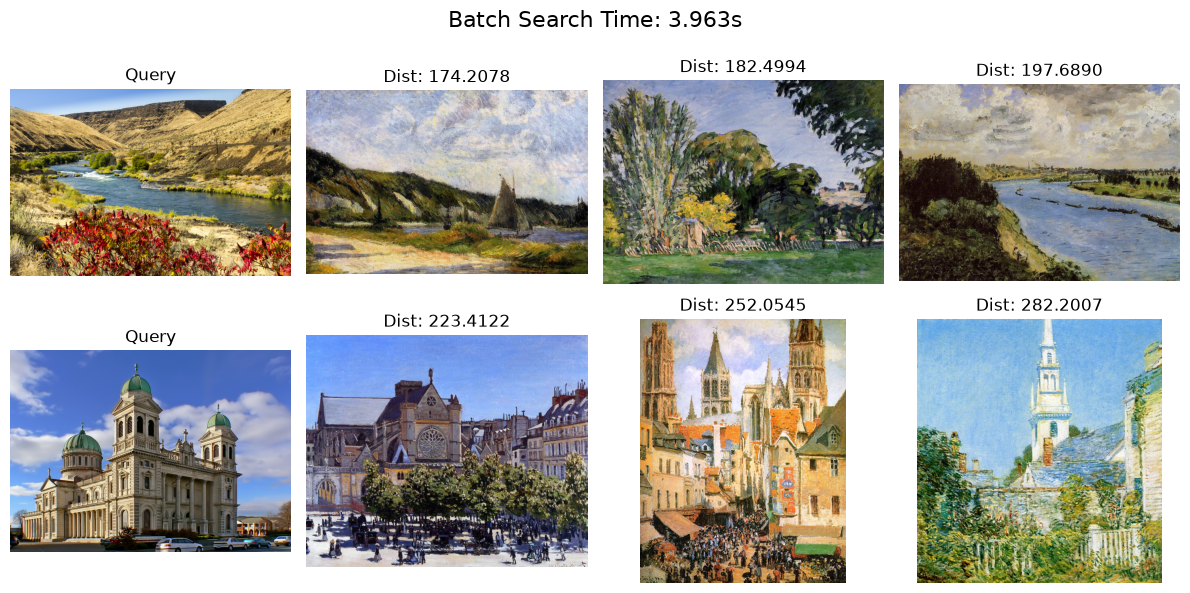

In [29]:
rows = len(data_batch[1])
cols = TOP_K + 1
fig, axarr=plt.subplots(rows, cols,figsize=(cols * 3, rows * 3),squeeze=False)

for hits_i, hits in enumerate(res):
    # 第一列：查询图片
    query_path = data_batch[1][hits_i]
    axarr[hits_i][0].imshow(Image.open(query_path))
    axarr[hits_i][0].axis('off')
    axarr[hits_i][0].set_title('Query')

    # 后续列：TOP_K 个搜索结果
    for hit_i, hit in enumerate(hits):
        if hit_i + 1 >= cols:
            break  # 防止结果不足 TOP_K 时越界
        result_path = hit.entity.get('filepath')
        axarr[hits_i][hit_i + 1].imshow(Image.open(result_path))
        axarr[hits_i][hit_i + 1].axis('off')
        axarr[hits_i][hit_i + 1].set_title(f'Dist: {hit.distance:.4f}')

# 可选：在画布顶部添加总耗时
fig.suptitle(f'Batch Search Time: {end_time - start:.3f}s', fontsize=16)
plt.tight_layout()
plt.savefig('batch_search_result.png', dpi=150, bbox_inches='tight')

In [21]:
data_batch=[[],[]]

for path in search_path:
    im=Image.open(path).convert('RGB')
    data_batch[0].append(preprocess(im))
    data_batch[1].append(path)

embeds_query=embed_query(data_batch[0],model)
start=time.time()
res=mc.search(
    collection_name=COLLECTION_NAME,
    data=embeds_query,
    search_params=SEARCH_PARAMS,
    limit=TOP_K,
    output_fields=["filepath"]
)
end_time=time.time()

print(end_time-start)
print(type(res))

4.184649229049683


We can plot the images for a visual.

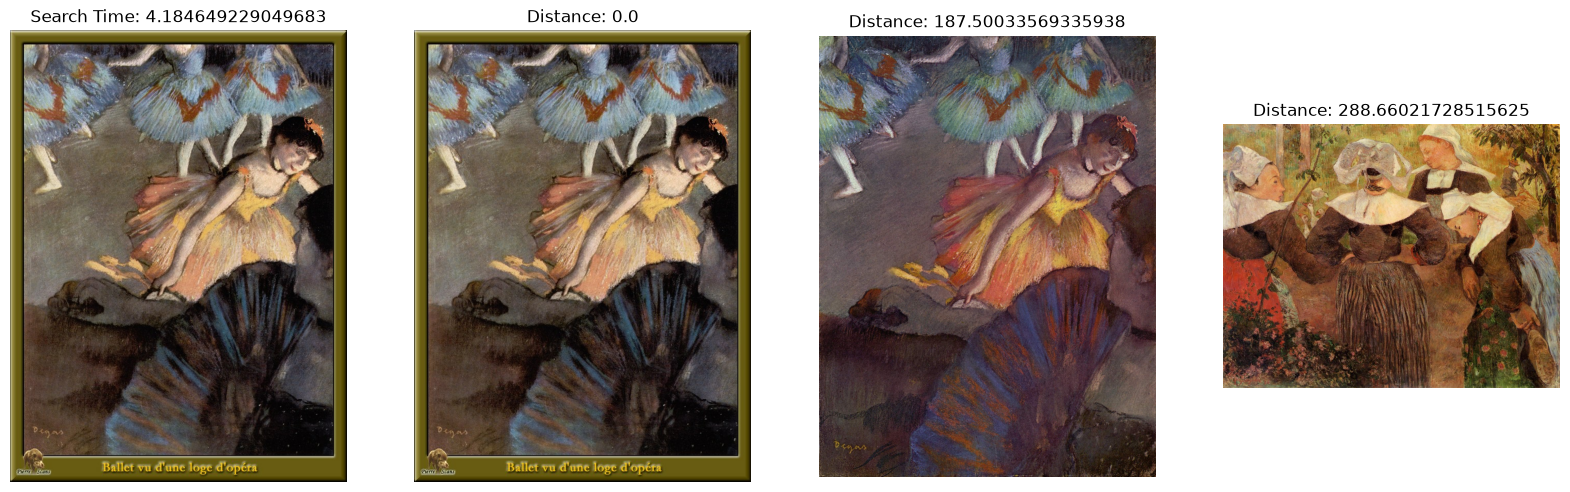

In [24]:
f, axarr=plt.subplots(len(data_batch[1]),TOP_K+1,figsize=(20,10),squeeze=False)

for hits_i,hits in enumerate(res):
    axarr[hits_i][0].imshow(Image.open(data_batch[1][hits_i]))
    axarr[hits_i][0].axis('off')
    axarr[hits_i][0].set_title('Search Time: '+ str(end_time-start))
    for hit_i,hit in enumerate(hits):
        axarr[hits_i][hit_i+1].imshow(Image.open(hit.entity.get('filepath')))
        axarr[hits_i][hit_i+1].axis('off')
        axarr[hits_i][hit_i+1].set_title('Distance: '+ str(hit.distance))

# Save the search result in a separate image file alongside your script.
plt.savefig('reverse_search_result.png')

We can also see which images were classified as the most similar.

In [25]:
for hits_i, hits in enumerate(res):
    for hit_it, hit in enumerate(hits):
        print(hit.entity)

{'id': 400, 'distance': 0.0, 'entity': {'id': 400, 'filepath': './paintings/paintings\\training\\training\\Degas\\213255.jpg'}}
{'id': 435, 'distance': 187.50033569335938, 'entity': {'id': 435, 'filepath': './paintings/paintings\\training\\training\\Degas\\213310.jpg'}}
{'id': 890, 'distance': 288.66021728515625, 'entity': {'id': 890, 'filepath': './paintings/paintings\\training\\training\\Gauguin\\190574.jpg'}}


In [30]:
mc.drop_collection(COLLECTION_NAME)